# Importing Libraries

- NumPy is used for numerical computations and matrix operations.
- Pandas is used for loading and handling the dataset.
- Matplotlib is used for visualization and plotting graphs.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Data Preprocessing

In this step:

- The diagnosis labels are saved separately for later evaluation and visualization.
- Unnecessary columns such as `id` and `Unnamed: 32` are removed.
- The diagnosis column is removed because clustering is an unsupervised learning task.
- The dataset is converted into a NumPy array for numerical processing.

In [10]:
# Save labels for later evaluation only
labels = df["diagnosis"]

# Remove unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32", "diagnosis"])

# Convert to NumPy array
X = df.values

print(X.shape)

(569, 30)


# Data Standardization

The dataset features are standardized before applying K-Means clustering.

Standardization is important because K-Means depends on distance calculations. Features with larger values may dominate the clustering process.


In [11]:
mean = np.mean(X, axis=0)

std = np.std(X, axis=0)

X_scaled = (X - mean) / std

print(X_scaled.shape)

(569, 30)


# K-Means Implementation

The K-Means clustering algorithm is implemented from scratch using NumPy.

Main steps of the algorithm:

1. Randomly initialize centroids.
2. Compute distances between points and centroids.
3. Assign each point to the nearest centroid.
4. Update centroid positions using cluster means.
5. Repeat the process until convergence.

The implementation also includes:
- SSE computation
- Empty cluster handling
- Convergence checking

In [12]:
class KMeans:
    
    def __init__(self, k=2, max_iters=100):

        self.k = k
        self.max_iters = max_iters


    # Initialize centroids randomly
    def initialize_centroids(self, X):

        indices = np.random.choice(
            X.shape[0],
            self.k,
            replace=False
        )

        centroids = X[indices]

        return centroids


    # Assign each point to nearest centroid
    def assign_clusters(self, X, centroids):

        distances = np.linalg.norm(
            X[:, np.newaxis] - centroids,
            axis=2
        )

        labels = np.argmin(distances, axis=1)

        return labels


    # Update centroid positions
    def update_centroids(self, X, labels):

        centroids = []

        for i in range(self.k):

            cluster_points = X[labels == i]

            # Handle empty clusters
            if len(cluster_points) == 0:

                centroid = X[
                    np.random.choice(X.shape[0])
                ]

            else:

                centroid = cluster_points.mean(axis=0)

            centroids.append(centroid)

        return np.array(centroids)


    # Compute SSE
    def compute_sse(self, X, labels, centroids):

        sse = 0

        for i in range(self.k):

            cluster_points = X[labels == i]

            sse += np.sum(
                (cluster_points - centroids[i]) ** 2
            )

        return sse


    # Train model
    def fit(self, X):

        centroids = self.initialize_centroids(X)

        for _ in range(self.max_iters):

            labels = self.assign_clusters(X, centroids)

            new_centroids = self.update_centroids(
                X,
                labels
            )

            # Stop if converged
            if np.allclose(centroids, new_centroids):

                break

            centroids = new_centroids

        sse = self.compute_sse(
            X,
            labels,
            centroids
        )

        self.centroids = centroids
        self.labels = labels
        self.sse = sse

# Running K-Means

The K-Means algorithm is executed using \(k = 2\) clusters.

After training:
- Cluster assignments are generated.
- Centroids are updated iteratively.
- The SSE value is computed to evaluate cluster compactness.

In [13]:
model = KMeans(k=2)

model.fit(X_scaled)

print("SSE =", model.sse)

SSE = 11595.683312822135


# Elbow Method

The elbow method is used to determine the optimal number of clusters.

The K-Means algorithm is executed using different values of \(k\), and the SSE is calculated for each case.

The optimal \(k\) is typically located near the "elbow" point where the SSE reduction becomes less significant.

In [14]:
sse_values = []

k_values = range(1, 11)

for k in k_values:

    model = KMeans(k=k)

    model.fit(X_scaled)

    sse_values.append(model.sse)

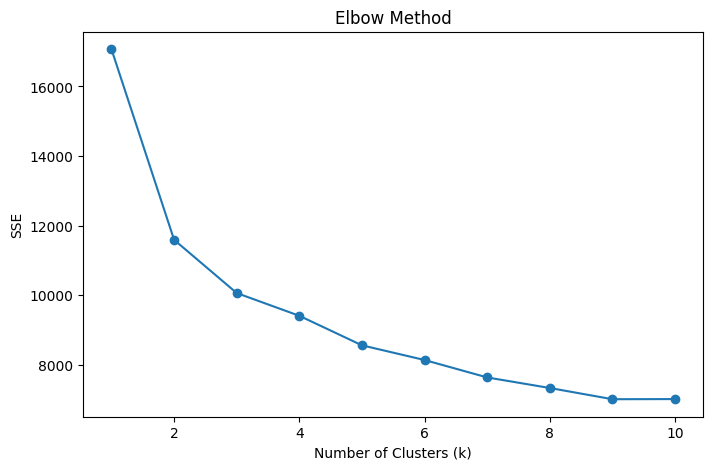

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    sse_values,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.title("Elbow Method")

plt.show()

# Multiple Initializations

K-Means is sensitive to random centroid initialization.

To improve clustering quality, the algorithm is executed multiple times with different random initializations, and the model with the lowest SSE is selected.

In [16]:
best_model = None

best_sse = float('inf')

for _ in range(10):

    model = KMeans(k=2)

    model.fit(X_scaled)

    if model.sse < best_sse:

        best_sse = model.sse

        best_model = model

print("Best SSE =", best_sse)

Best SSE = 11595.526607115786


# Cluster Visualization

The clustering results are visualized using a scatter plot.

- Different colors represent different clusters.
- The large "X" markers represent cluster centroids.

This visualization helps understand how the data points are grouped.

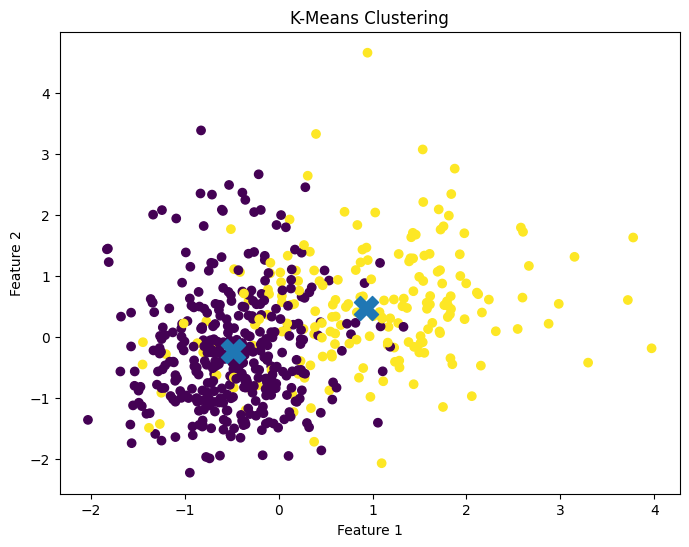

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=best_model.labels
)

plt.scatter(
    best_model.centroids[:, 0],
    best_model.centroids[:, 1],
    s=300,
    marker='X'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("K-Means Clustering")

plt.show()